# 02 Train ARIMA Models
## Secchi Depth & Trophic State Index (TSI)

This notebook includes:
1. Model evaluation using time-based train/test split
2. ARIMA hyperparameter selection (restricted grid search)
3. Final model training using full dataset
4. Forecasting for real-world deployment


Cell 2: Import Libraries

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

plt.rcParams["figure.figsize"] = (10, 4)


Cell 3: Define Paths

In [27]:
DATA_DIR = "../data_prepared"
MODEL_DIR = "../models_arima"
RESULT_DIR = "../results_arima"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


Cell 4: Utility Functions

In [28]:
def train_test_split_ts(series, train_ratio=0.8):
    split_idx = int(len(series) * train_ratio)
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]
    return train, test


def check_stationarity(series):
    result = adfuller(series)
    return result[1]  # p-value


def arima_grid_search(series, p_range, d_range, q_range):
    best_aic = np.inf
    best_order = None

    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(series, order=(p, d, q))
                    model_fit = model.fit()
                    if model_fit.aic < best_aic:
                        best_aic = model_fit.aic
                        best_order = (p, d, q)
                except:
                    continue

    return best_order, best_aic


Cell 5: ARIMA Evaluation Function

In [29]:
def evaluate_arima(series, order):
    train, test = train_test_split_ts(series)

    model = ARIMA(train, order=order)
    model_fit = model.fit()

    predictions = model_fit.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)

    return rmse, mae


Cell 6: Loop – Evaluation + Final Training (All Stations)

In [30]:
summary = []

for file in os.listdir(DATA_DIR):
    if not file.endswith("_prepared.csv"):
        continue

    station = file.split("_")[0]
    print(f"\n🔹 Processing station: {station}")

    df = pd.read_csv(
        os.path.join(DATA_DIR, file),
        index_col="Date",
        parse_dates=True
    )

    station_dir = os.path.join(MODEL_DIR, station)
    os.makedirs(station_dir, exist_ok=True)

    # ===============================
    # SECCHI DEPTH
    # ===============================
    secchi = df["Secchi_Depth"]

    pval = check_stationarity(secchi)
    d_range = [0] if pval < 0.05 else [1]

    order_secchi, aic_secchi = arima_grid_search(
        secchi,
        p_range=[0, 1, 2],
        d_range=d_range,
        q_range=[0, 1, 2]
    )

    rmse_s, mae_s = evaluate_arima(secchi, order_secchi)

    # Final training (full data)
    final_secchi_model = ARIMA(secchi, order=order_secchi).fit()
    joblib.dump(final_secchi_model, f"{station_dir}/secchi_arima.pkl")

    # ===============================
    # TSI
    # ===============================
    tsi = df["TSI"]

    pval = check_stationarity(tsi)
    d_range = [0] if pval < 0.05 else [1]

    order_tsi, aic_tsi = arima_grid_search(
        tsi,
        p_range=[0, 1, 2],
        d_range=d_range,
        q_range=[0, 1, 2]
    )

    rmse_t, mae_t = evaluate_arima(tsi, order_tsi)

    # Final training (full data)
    final_tsi_model = ARIMA(tsi, order=order_tsi).fit()
    joblib.dump(final_tsi_model, f"{station_dir}/tsi_arima.pkl")

    summary.append([
        station,
        order_secchi, aic_secchi, rmse_s, mae_s,
        order_tsi, aic_tsi, rmse_t, mae_t
    ])



🔹 Processing station: CP01


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe


🔹 Processing station: LS01


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe


🔹 Processing station: LS03


...

D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe


🔹 Processing station: TP01


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe


🔹 Processing station: TP04


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

Cell 7: Save & Display Evaluation Results

In [31]:
summary_df = pd.DataFrame(
    summary,
    columns=[
        "Station",
        "Secchi_ARIMA_Order", "Secchi_AIC", "Secchi_RMSE", "Secchi_MAE",
        "TSI_ARIMA_Order", "TSI_AIC", "TSI_RMSE", "TSI_MAE"
    ]
)

summary_df.to_csv(f"{RESULT_DIR}/arima_evaluation_summary.csv", index=False)
summary_df


,Station,Secchi_ARIMA_Order,Secchi_AIC,Secchi_RMSE,Secchi_MAE,TSI_ARIMA_Order,TSI_AIC,TSI_RMSE,TSI_MAE
0,CP01,"(0, 1, 1)",40.909466,0.107262,0.082870,"(2, 0, 1)",531.867731,1.120618,0.870251
1,LS01,"(1, 0, 2)",288.258518,0.339960,0.312602,"(2, 0, 0)",1072.672873,1.669490,1.356573
2,LS03,"(1, 0, 0)",-201.209354,0.114931,0.098451,"(1, 0, 2)",623.367670,1.492694,1.311259
3,PN01,"(0, 0, 1)",-191.134736,0.113690,0.102368,"(2, 0, 2)",711.268472,2.201129,1.819694
4,SK01,"(1, 0, 0)",-118.049275,0.066826,0.056888,"(0, 0, 1)",458.039523,3.005446,2.450680
5,SK06,"(0, 0, 2)",-198.188638,0.080810,0.054030,"(1, 0, 0)",318.066733,1.009481,0.889646
6,TP011,"(1, 0, 0)",-223.950982,0.043046,0.034871,"(1, 1, 1)",324.676476,3.654266,3.438949
7,TP01,"(2, 0, 2)",-65.182792,0.176253,0.149076,"(1, 0, 1)",526.011114,1.210539,0.897907
8,TP04,"(2, 0, 1)",-178.268119,0.077503,0.067843,"(2, 0, 1)",557.880841,1.329152,1.083170


Cell 8: Forecast Example (Demo for 1 Station)

D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


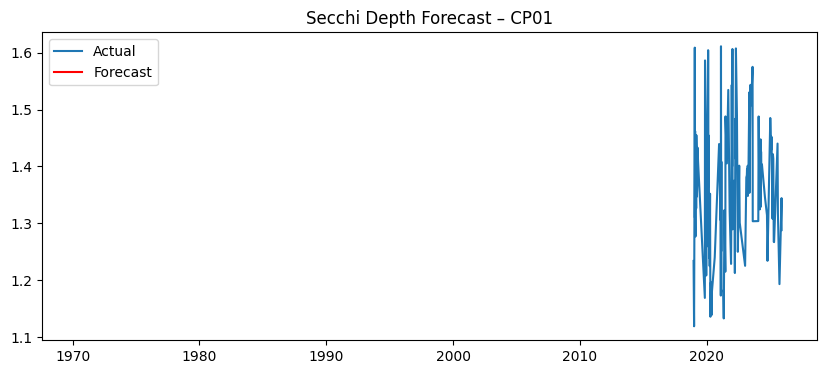

In [32]:
example_station = summary_df.iloc[0]["Station"]
model_path = f"{MODEL_DIR}/{example_station}/secchi_arima.pkl"

model = joblib.load(model_path)
forecast = model.forecast(steps=12)

plt.figure()
plt.plot(df["Secchi_Depth"], label="Actual")
plt.plot(forecast.index, forecast, label="Forecast", color="red")
plt.legend()
plt.title(f"Secchi Depth Forecast – {example_station}")
plt.show()


## Conclusion

- ARIMA models were evaluated using time-based train/test split
- Hyperparameters were selected using restricted grid search (AIC)
- Final models were trained using full datasets
- Models were saved per station for real-world deployment
